# nb06 -- Confound-corrected sparse MLP: RNA -> protein
Extends nb05 with two corrections:

1. **Library-size regression** -- removes the "everything scales together" artifact (ACTB/EEF1A1/HBB dominating as top predictors in nb05) by regressing out per-cell RNA and ADT library size before training. This is a technical confound, not biology, so it's removed.
2. **Cell-type-stratified training** -- trains a separate model per cell type on the corrected residuals, so genuine cell-type-specific coupling (the real effector/naive-style gradient from nb02) is preserved rather than averaged away.

Training runs on GPU; validation during training and all post-training evaluation run on CPU.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-misc
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


In [2]:
!pip install -q -U "typing_extensions>=4.13"


## GPU check

In [3]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


## Imports and config

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
RESULTS_DIR        = BASE_PATH / 'results' / 'sparse_mlp_corrected'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
FIGURES_DIR        = RESULTS_DIR / 'figures'
for d in (MODELS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM   = 64
L1_LAMBDA    = 1e-4
BATCH_SIZE   = 256
NUM_EPOCHS   = 100
PATIENCE     = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

MIN_CELLS_PER_TYPE = 500   # skip cell types too small to fit reliably
N_PLOT_PAIRS        = 12   # how many pairs to show inline (full set always saved to PDF)

## Load checkpoint and gene mapping
Same as nb03/nb05.

In [5]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## Identify the cell-type column
nb03 never used cell type, so the exact `obs` column name isn't established yet -- print all columns and auto-detect likely candidates. **Check the printed list and set `CELL_TYPE_COL` manually below if the guess is wrong** before running the rest of the notebook.

In [6]:
print('All obs columns:')
print(covid.obs.columns.tolist())

candidates = [c for c in covid.obs.columns if any(
    kw in c.lower() for kw in ['cell_type', 'celltype', 'cluster', 'annotation', 'subset', 'lineage']
)]
print('\nLikely cell-type columns:', candidates)

All obs columns:
['sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id']

Likely cell-type columns: ['full_clustering', 'initial_clustering']


In [7]:
# CONFIRM/OVERRIDE this before proceeding -- pick the column that holds cell-type labels.
CELL_TYPE_COL = candidates[0] if candidates else 'full_clustering'

print(f'Using CELL_TYPE_COL = "{CELL_TYPE_COL}"')
print(covid.obs[CELL_TYPE_COL].value_counts())

Using CELL_TYPE_COL = "full_clustering"
full_clustering
CD4.CM                   12501
NK_16hi                   8646
CD4.Naive                 6759
B_naive                   5922
CD8.Naive                 5587
CD4.IL22                  5488
CD8.TE                    2857
CD83_CD14_mono            2505
CD8.EM                    2431
CD4.Tfh                   2419
Platelets                 2245
gdT                       1897
MAIT                      1763
NK_56hi                   1182
RBC                       1079
B_switched_memory         1062
B_immature                 724
B_non-switched_memory      422
DC3                        393
NKT                        366
B_exhausted                268
Plasma_cell_IgG            247
CD4.EM                     246
Plasma_cell_IgA            238
CD4.Th1                    193
NK_prolif                  193
CD16_mono                  184
pDC                        171
ILC1_3                     156
Treg                       151
Plasmablast   

## Gene union (matched + HVG)
Same construction as nb03/nb05.

In [8]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 2092


## Normalize RNA and protein (pre-totalVI), same as nb05
RNA: log1p(CP10k). Protein: CLR. Both independent of totalVI's batch-corrected output.

In [9]:
def normalize_rna(adata_gex: sc.AnnData, gene_union: list[str]) -> sc.AnnData:
    """Log1p(CP10k) normalization on raw counts, restricted to gene_union."""
    adata = adata_gex[:, gene_union].copy()
    adata.X = adata.layers['raw'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata


def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """Centered log-ratio normalization per cell -- standard for CITE-seq ADT counts."""
    log_counts = np.log1p(counts)
    geometric_mean = log_counts.mean(axis=1, keepdims=True)
    return log_counts - geometric_mean


rna_adata = normalize_rna(covid_gex, gene_union)
X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

cell_types = covid.obs[CELL_TYPE_COL].values

print(f'X_rna: {X_rna.shape} | Y_protein: {Y_protein.shape}')

X_rna: (69090, 2092) | Y_protein: (69090, 163)


## Library-size correction (option a)
Regress each gene/protein on its modality's per-cell log library size and keep the residual. This removes the technical "cells with more total RNA/protein have higher everything" effect -- the likely source of ACTB/EEF1A1/HBB dominating nb05's importance rankings -- without touching cell-type identity itself. Vectorized closed-form OLS: same covariate for every column, solved once via `lstsq`.

In [10]:
def regress_out_library_size(X: np.ndarray, raw_counts_layer: np.ndarray) -> np.ndarray:
    """Residualize each column of X against log1p(per-cell total raw counts).

    X                : (n_cells, n_features) normalized values to correct.
    raw_counts_layer : (n_cells, n_features_raw) raw counts used only to compute library size.
    """
    lib_size = np.log1p(np.asarray(raw_counts_layer).sum(axis=1)).reshape(-1, 1)
    design = np.column_stack([np.ones(X.shape[0]), lib_size])
    beta, _, _, _ = np.linalg.lstsq(design, X, rcond=None)  # (2, n_features)
    return (X - design @ beta).astype(np.float32)


rna_raw_for_size = rna_adata.layers['raw'] if hasattr(rna_adata.layers['raw'], 'sum') else rna_adata.layers['raw']
rna_raw_for_size = np.asarray(rna_raw_for_size.todense()) if hasattr(rna_raw_for_size, 'todense') else np.asarray(rna_raw_for_size)

X_rna_corr     = regress_out_library_size(X_rna, rna_raw_for_size)
Y_protein_corr = regress_out_library_size(Y_protein, adt_counts)

print('Corrected X_rna and Y_protein via library-size regression.')

Corrected X_rna and Y_protein via library-size regression.


## Train / val / test split
Same simple random 70/15/15 split as nb05.

In [11]:
n_cells = X_rna_corr.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders (global model)

In [12]:
def make_loader(X: np.ndarray, Y: np.ndarray, idx: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X[idx]), torch.from_numpy(Y[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


train_loader = make_loader(X_rna_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

## `SparseGeneToProteinMLP` architecture
Unchanged from nb05.

In [13]:
class SparseGeneToProteinMLP(nn.Module):
    """RNA -> hidden -> protein, multi-output regression.

    rna_dim     : number of input genes.
    hidden_dim  : hidden layer width.
    protein_dim : number of output proteins, predicted jointly.
    """

    def __init__(self, rna_dim: int, hidden_dim: int, protein_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(rna_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, protein_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc2(self.relu(self.fc1(x)))

## Training loop -- GPU for training, CPU for validation
Model moves to GPU only for the training pass each epoch; validation runs with the model on CPU. Final returned model is left on CPU, matching the CPU-only evaluation that follows.

In [14]:
def fit_sparse_mlp(model: nn.Module,
                    train_loader: DataLoader,
                    val_loader: DataLoader,
                    l1_lambda: float,
                    num_epochs: int,
                    patience: int,
                    checkpoint_path: Path,
                    train_device: torch.device):
    """Train with MSE + L1(fc1.weight) on train_device; validate on CPU each epoch."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.to(train_device)
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(train_device), yb.to(train_device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb) + l1_lambda * model.fc1.weight.abs().sum()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.to('cpu')
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'  Early stopping at epoch {epoch}')
                break

        if epoch % 10 == 0:
            print(f'  Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    model.load_state_dict(best_state)
    model.to('cpu')
    torch.save(model.state_dict(), checkpoint_path)
    return model, history

## Train the global model (all cells, corrected residuals)

In [15]:
print('Training global model...')
global_model = SparseGeneToProteinMLP(
    rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
)
global_model, global_history = fit_sparse_mlp(
    model=global_model,
    train_loader=train_loader,
    val_loader=val_loader,
    l1_lambda=L1_LAMBDA,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=MODELS_DIR / 'global_model.pt',
    train_device=DEVICE,
)

Training global model...
  Epoch 0: train_loss=0.3288, val_loss=0.2774
  Epoch 10: train_loss=0.2787, val_loss=0.2608
  Epoch 20: train_loss=0.2756, val_loss=0.2578
  Epoch 30: train_loss=0.2743, val_loss=0.2576
  Epoch 40: train_loss=0.2736, val_loss=0.2560
  Epoch 50: train_loss=0.2732, val_loss=0.2556
  Epoch 60: train_loss=0.2727, val_loss=0.2557
  Epoch 70: train_loss=0.2728, val_loss=0.2556
  Epoch 80: train_loss=0.2724, val_loss=0.2557
  Epoch 90: train_loss=0.2724, val_loss=0.2552
  Early stopping at epoch 97


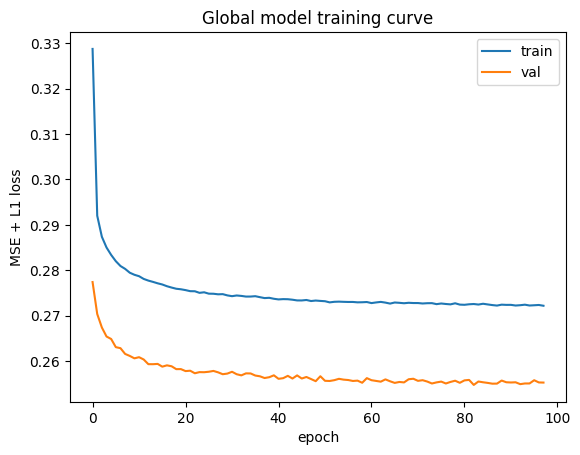

In [16]:
plt.plot(global_history['train_loss'], label='train')
plt.plot(global_history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('MSE + L1 loss')
plt.legend()
plt.title('Global model training curve')
plt.show()

## Train cell-type-stratified models (option c)
One model per cell type with enough cells, trained on the same corrected residuals but restricted to that cell type. Real cell-type-specific coupling is allowed to differ; nothing is forced equal across cell types.

In [17]:
type_counts = pd.Series(cell_types).value_counts()
fit_types = type_counts[type_counts >= MIN_CELLS_PER_TYPE].index.tolist()
print(f'Fitting {len(fit_types)} cell types (>= {MIN_CELLS_PER_TYPE} cells): {fit_types}')

celltype_models = {}
celltype_histories = {}
celltype_splits = {}

for ct in fit_types:
    print(f'\n--- {ct} ---')
    ct_idx = np.where(cell_types == ct)[0]

    ct_train, ct_test = train_test_split(ct_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    ct_train, ct_val  = train_test_split(ct_train, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)
    celltype_splits[ct] = {'train': ct_train, 'val': ct_val, 'test': ct_test}

    ct_train_loader = make_loader(X_rna_corr, Y_protein_corr, ct_train, BATCH_SIZE, shuffle=True)
    ct_val_loader   = make_loader(X_rna_corr, Y_protein_corr, ct_val,   BATCH_SIZE, shuffle=False)

    ct_model = SparseGeneToProteinMLP(
        rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
    )
    safe_name = ct.replace(' ', '_').replace('/', '_')
    ct_model, ct_history = fit_sparse_mlp(
        model=ct_model,
        train_loader=ct_train_loader,
        val_loader=ct_val_loader,
        l1_lambda=L1_LAMBDA,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        checkpoint_path=MODELS_DIR / f'celltype_{safe_name}.pt',
        train_device=DEVICE,
    )
    celltype_models[ct] = ct_model
    celltype_histories[ct] = ct_history

Fitting 17 cell types (>= 500 cells): ['CD4.CM', 'NK_16hi', 'CD4.Naive', 'B_naive', 'CD8.Naive', 'CD4.IL22', 'CD8.TE', 'CD83_CD14_mono', 'CD8.EM', 'CD4.Tfh', 'Platelets', 'gdT', 'MAIT', 'NK_56hi', 'RBC', 'B_switched_memory', 'B_immature']

--- CD4.CM ---
  Epoch 0: train_loss=0.3621, val_loss=0.2787
  Epoch 10: train_loss=0.2584, val_loss=0.2485
  Epoch 20: train_loss=0.2535, val_loss=0.2468
  Epoch 30: train_loss=0.2504, val_loss=0.2470
  Early stopping at epoch 35

--- NK_16hi ---
  Epoch 0: train_loss=0.4286, val_loss=0.3089
  Epoch 10: train_loss=0.2606, val_loss=0.2608
  Epoch 20: train_loss=0.2550, val_loss=0.2573
  Epoch 30: train_loss=0.2523, val_loss=0.2566
  Epoch 40: train_loss=0.2503, val_loss=0.2569
  Early stopping at epoch 50

--- CD4.Naive ---
  Epoch 0: train_loss=0.3815, val_loss=0.2885
  Epoch 10: train_loss=0.2552, val_loss=0.2562
  Epoch 20: train_loss=0.2477, val_loss=0.2556
  Early stopping at epoch 30

--- B_naive ---
  Epoch 0: train_loss=0.5634, val_loss=0.348

## Evaluation function (CPU only)
Used for every model below -- global and per-cell-type -- with a `predictions=True` option to also return raw predictions for the scatter plots.

In [18]:
def evaluate_per_protein(model: nn.Module, X: np.ndarray, Y: np.ndarray,
                          protein_names: list[str], return_preds: bool = False):
    """Per-protein Pearson r and R2 on CPU. Optionally also return raw predictions."""
    model.to('cpu')
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X)).numpy()
    rows = []
    for i, name in enumerate(protein_names):
        r, _ = pearsonr(Y[:, i], preds[:, i])
        r2 = r2_score(Y[:, i], preds[:, i])
        rows.append({'protein': name, 'pearson_r': r, 'r2': r2})
    metrics = pd.DataFrame(rows)
    return (metrics, preds) if return_preds else metrics

## Global model: per-protein metrics, train vs test
Same comparison as nb05, now on the corrected residuals.

In [19]:
global_train_metrics, global_train_preds = evaluate_per_protein(
    global_model, X_rna_corr[train_idx], Y_protein_corr[train_idx], matched_adt_names, return_preds=True,
)
global_test_metrics, global_test_preds = evaluate_per_protein(
    global_model, X_rna_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names, return_preds=True,
)

global_metrics = global_train_metrics.merge(global_test_metrics, on='protein', suffixes=('_train', '_test'))
global_metrics['r_gap'] = global_metrics['pearson_r_train'] - global_metrics['pearson_r_test']
global_metrics = global_metrics.sort_values('pearson_r_test', ascending=False).reset_index(drop=True)

print(f"Median test Pearson r (corrected): {global_metrics['pearson_r_test'].median():.3f}")
global_metrics.head(20)

Median test Pearson r (corrected): 0.442


,protein,pearson_r_train,r2_train,pearson_r_test,r2_test,r_gap
0,AB_CD4,0.878439,0.771336,0.875520,0.766065,0.002920
1,AB_CD5,0.880004,0.774402,0.875273,0.766072,0.004731
2,AB_CD19,0.862916,0.744621,0.861010,0.741274,0.001906
3,AB_CD3,0.862710,0.744261,0.861001,0.741205,0.001709
4,AB_CD8,0.849448,0.721535,0.850840,0.723837,-0.001391
5,AB_CD21,0.846012,0.715698,0.842837,0.710244,0.003175
6,AB_CD2,0.838247,0.702649,0.831557,0.691371,0.006690
7,AB_CD28,0.818558,0.670028,0.812905,0.660787,0.005652
8,AB_FCGR2A,0.816840,0.667107,0.807522,0.651635,0.009318
9,AB_CD20,0.810675,0.657026,0.806130,0.649754,0.004545


## Per-cell-type evaluation
Two views side by side: how the global model performs *within* each cell type's test cells, vs. how the dedicated per-cell-type model performs on its own held-out cells. If they diverge, coupling is genuinely cell-type-specific; if they agree, the global model already captures it.

In [20]:
celltype_eval_rows = []

for ct in fit_types:
    ct_test_idx = celltype_splits[ct]['test']

    global_on_ct = evaluate_per_protein(
        global_model, X_rna_corr[ct_test_idx], Y_protein_corr[ct_test_idx], matched_adt_names,
    )
    stratified_on_ct = evaluate_per_protein(
        celltype_models[ct], X_rna_corr[ct_test_idx], Y_protein_corr[ct_test_idx], matched_adt_names,
    )

    merged = global_on_ct.merge(stratified_on_ct, on='protein', suffixes=('_global', '_stratified'))
    merged['cell_type'] = ct
    merged['n_test_cells'] = len(ct_test_idx)
    celltype_eval_rows.append(merged)

celltype_eval = pd.concat(celltype_eval_rows, ignore_index=True)

summary = celltype_eval.groupby('cell_type').agg(
    n_test_cells=('n_test_cells', 'first'),
    median_r_global=('pearson_r_global', 'median'),
    median_r_stratified=('pearson_r_stratified', 'median'),
).reset_index()
summary['stratified_gain'] = summary['median_r_stratified'] - summary['median_r_global']
summary = summary.sort_values('stratified_gain', ascending=False)
summary

,cell_type,n_test_cells,median_r_global,median_r_stratified,stratified_gain
15,RBC,162,0.430106,0.400203,-0.029903
3,CD4.CM,1876,0.310929,0.278214,-0.032715
12,NK_16hi,1297,0.306726,0.267801,-0.038926
8,CD8.Naive,839,0.296780,0.250975,-0.045805
10,CD83_CD14_mono,376,0.264486,0.214669,-0.049817
5,CD4.Naive,1014,0.251391,0.201056,-0.050335
1,B_naive,889,0.301653,0.251024,-0.050629
4,CD4.IL22,824,0.302167,0.244725,-0.057441
9,CD8.TE,429,0.295813,0.226652,-0.069162
14,Platelets,337,0.352364,0.274882,-0.077482


## Gene importance and cognate rank (global model, corrected)
Same path-weight approach as nb05, recomputed on the corrected model.

In [21]:
def compute_gene_importance(model: nn.Module, gene_names: list[str], protein_names: list[str]) -> pd.DataFrame:
    """|W2 @ W1| path-weight importance, shape (n_proteins, n_genes)."""
    model.to('cpu')
    W1 = model.fc1.weight.detach().numpy()  # (hidden, genes)
    W2 = model.fc2.weight.detach().numpy()  # (proteins, hidden)
    importance = np.abs(W2 @ W1)
    return pd.DataFrame(importance, index=protein_names, columns=gene_names)


def cognate_gene_rank(importance_df: pd.DataFrame, gene_map: pd.DataFrame) -> pd.DataFrame:
    """Rank of each protein's cognate RNA gene by importance score (1 = top predictor)."""
    rows = []
    for _, row in gene_map.iterrows():
        gene, adt = row['gene'], row['adt_name']
        if adt not in importance_df.index or gene not in importance_df.columns:
            continue
        ranks = importance_df.loc[adt].rank(ascending=False)
        top_gene = importance_df.loc[adt].idxmax()
        rows.append({
            'protein': adt,
            'cognate_gene': gene,
            'cognate_rank': int(ranks[gene]),
            'n_genes': len(ranks),
            'top_predictor_gene': top_gene,
        })
    return pd.DataFrame(rows).sort_values('cognate_rank').reset_index(drop=True)


importance_df = compute_gene_importance(global_model, gene_union, matched_adt_names)
cognate_ranks = cognate_gene_rank(importance_df, gene_map)

print(f"Proteins where cognate RNA is the #1 predictor (corrected): {(cognate_ranks['cognate_rank'] == 1).sum()} / {len(cognate_ranks)}")
print(f"(nb05, uncorrected, was 8 / 163)")
cognate_ranks.head(20)

Proteins where cognate RNA is the #1 predictor (corrected): 6 / 163
(nb05, uncorrected, was 8 / 163)


,protein,cognate_gene,cognate_rank,n_genes,top_predictor_gene
0,AB_CD123,IL3RA,1,2092,IL3RA
1,AB_CCR4,CCR4,1,2092,CCR4
2,AB_KLRG1,KLRG1,1,2092,KLRG1
3,AB_CD16,FCGR3A,1,2092,FCGR3A
4,AB_CD161,KLRB1,1,2092,KLRB1
5,AB_KIR3DL1,KIR3DL1,1,2092,KIR3DL1
6,AB_CD8,CD8A,2,2092,CD8B
7,AB_CD20,MS4A1,2,2092,EEF1A1
8,AB_CD62L,SELL,2,2092,EEF1A1
9,AB_IL7R,IL7R,2,2092,EEF1A1


## Scatter plots: RNA vs. protein (real and predicted)
For each cognate pair, RNA on x, real protein and model-predicted protein both on y. Top pairs by fit shown inline; the full 163-pair set is saved as a multi-page PDF.

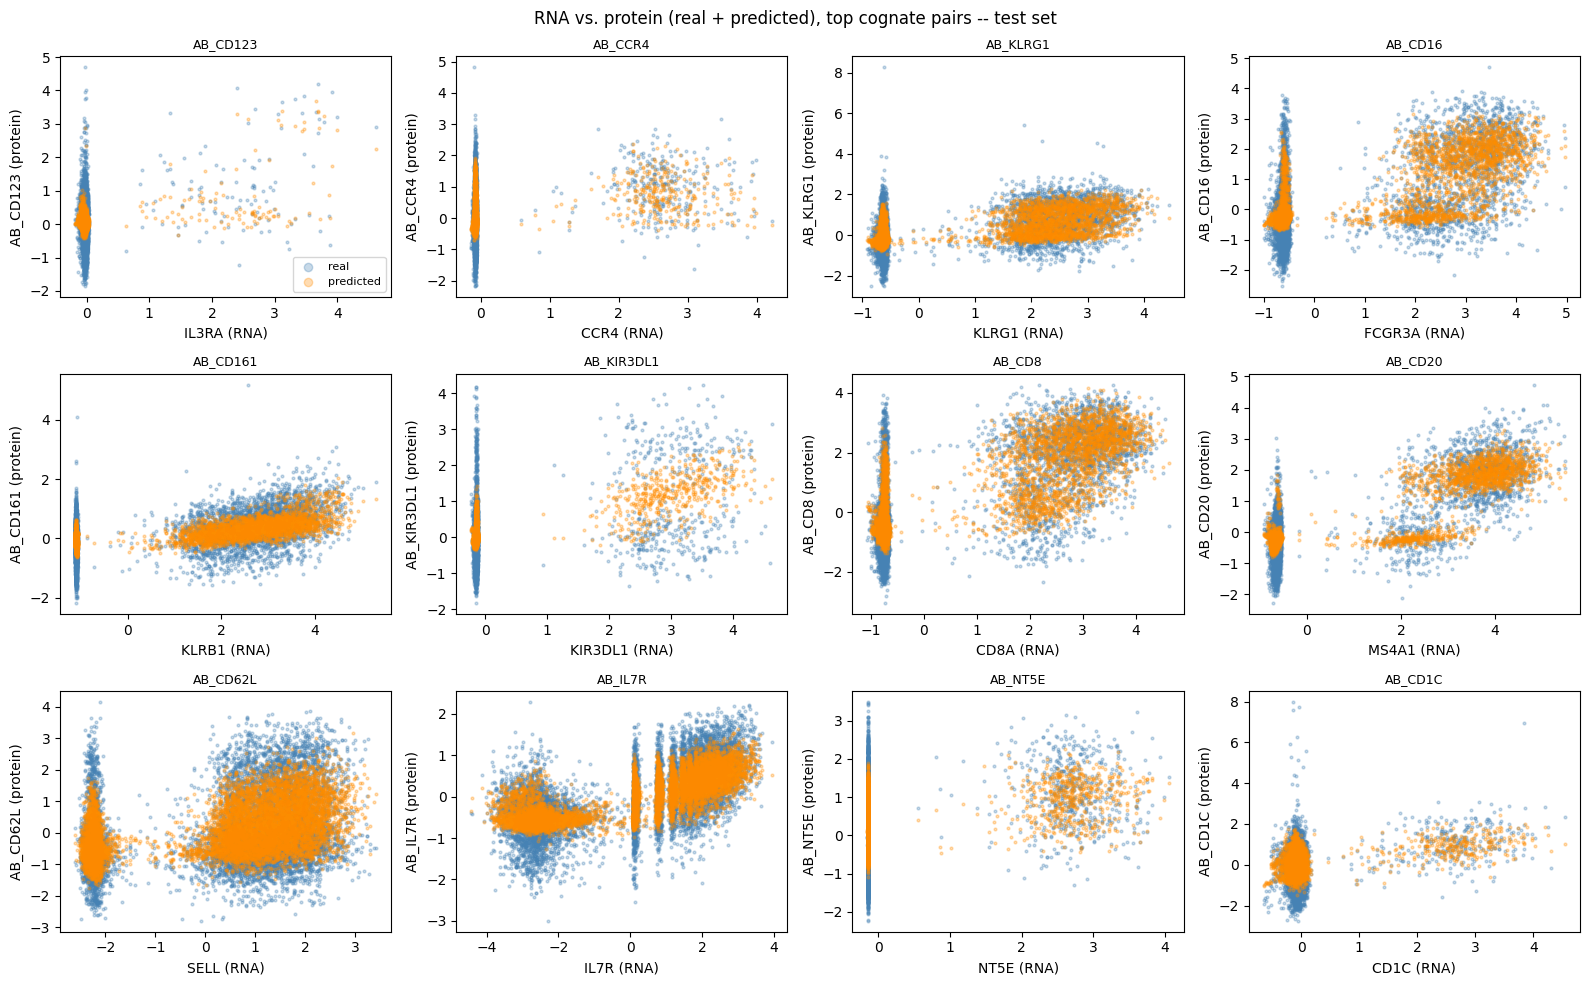

In [22]:
gene_idx_map = {g: i for i, g in enumerate(gene_union)}
protein_idx_map = {p: i for i, p in enumerate(matched_adt_names)}


def plot_rna_vs_protein(ax, gene: str, protein: str,
                         X: np.ndarray, Y_real: np.ndarray, Y_pred: np.ndarray):
    """RNA (x) vs. real and predicted protein (y) on a single axis."""
    gi, pi = gene_idx_map[gene], protein_idx_map[protein]
    x = X[:, gi]
    ax.scatter(x, Y_real[:, pi], s=4, alpha=0.3, color='steelblue', label='real')
    ax.scatter(x, Y_pred[:, pi], s=4, alpha=0.3, color='darkorange', label='predicted')
    ax.set_xlabel(f'{gene} (RNA)')
    ax.set_ylabel(f'{protein} (protein)')
    ax.set_title(protein, fontsize=9)


top_pairs = cognate_ranks.head(N_PLOT_PAIRS)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, (_, row) in zip(axes.flat, top_pairs.iterrows()):
    plot_rna_vs_protein(ax, row['cognate_gene'], row['protein'], X_rna_corr[test_idx], Y_protein_corr[test_idx], global_test_preds)
axes.flat[0].legend(markerscale=3, fontsize=8)
fig.suptitle('RNA vs. protein (real + predicted), top cognate pairs -- test set')
fig.tight_layout()
plt.show()

In [23]:
# Full set (all 163 cognate pairs), saved to PDF -- not displayed inline
with PdfPages(FIGURES_DIR / 'rna_vs_protein_all_pairs.pdf') as pdf:
    for _, row in cognate_ranks.iterrows():
        fig, ax = plt.subplots(figsize=(5, 4))
        plot_rna_vs_protein(ax, row['cognate_gene'], row['protein'], X_rna_corr[test_idx], Y_protein_corr[test_idx], global_test_preds)
        ax.legend(markerscale=3, fontsize=8)
        pdf.savefig(fig)
        plt.close(fig)

print(f'Saved all {len(cognate_ranks)} RNA-vs-protein plots to {FIGURES_DIR / "rna_vs_protein_all_pairs.pdf"}')

Saved all 163 RNA-vs-protein plots to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_corrected/figures/rna_vs_protein_all_pairs.pdf


## Scatter plots: predicted vs. real protein (calibration)
Direct check of model fit per protein -- points on the diagonal mean accurate prediction.

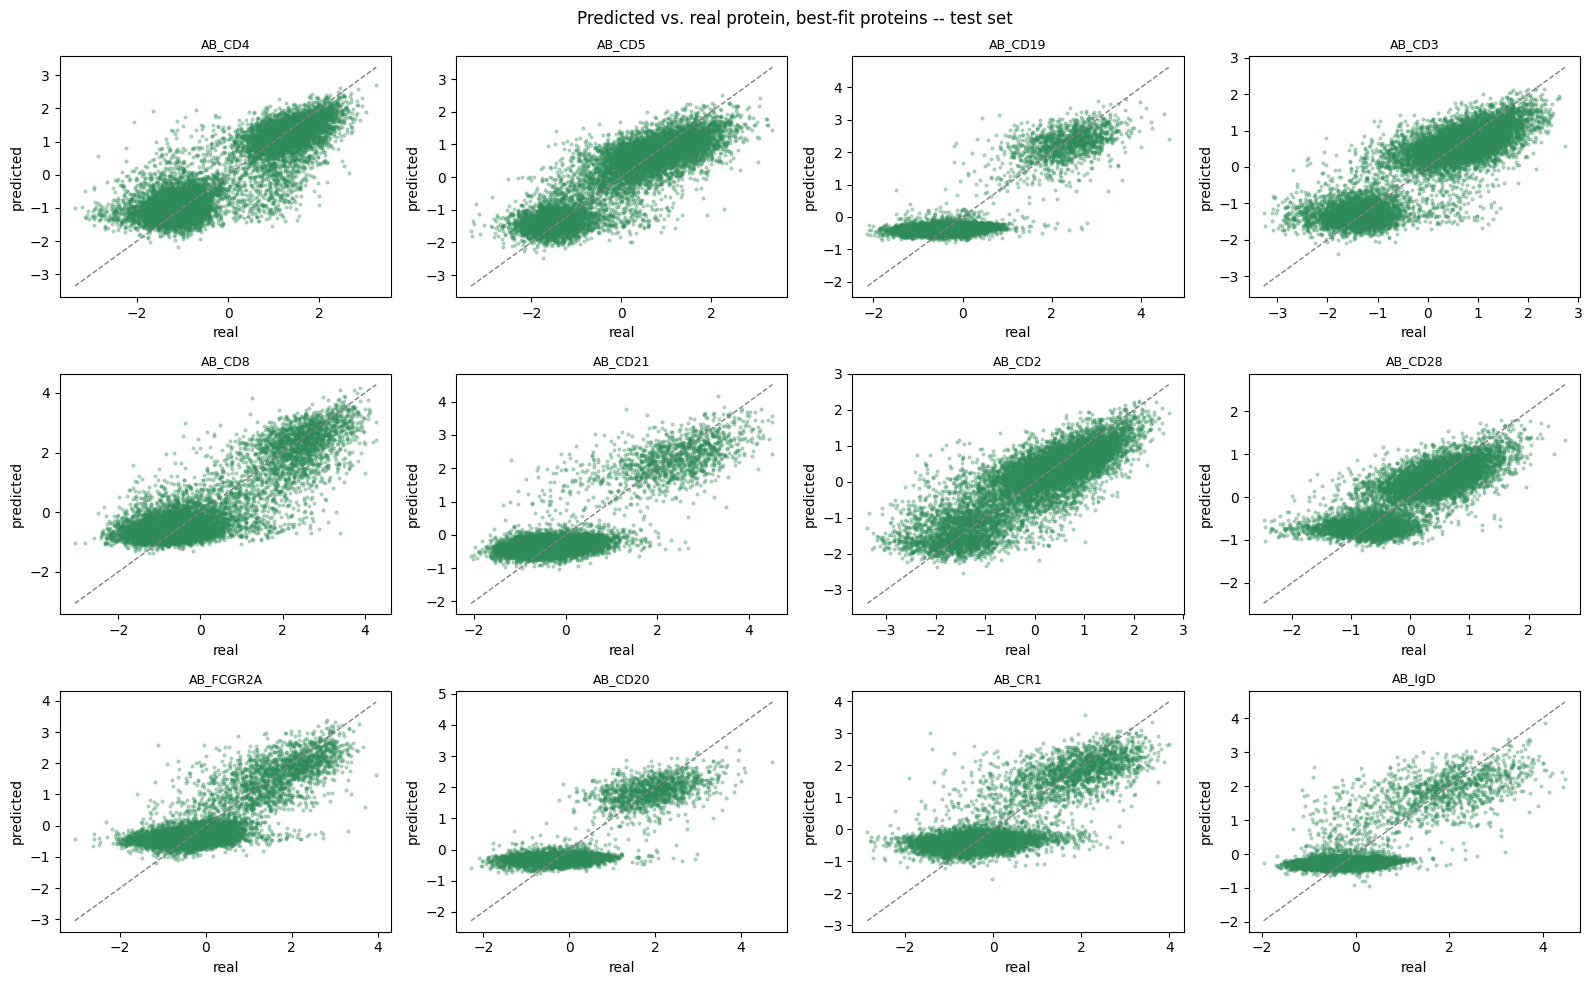

In [24]:
def plot_pred_vs_real(ax, protein: str, Y_real: np.ndarray, Y_pred: np.ndarray):
    """Predicted (y) vs. real (x) protein value, with the y=x reference line."""
    pi = protein_idx_map[protein]
    real, pred = Y_real[:, pi], Y_pred[:, pi]
    ax.scatter(real, pred, s=4, alpha=0.3, color='seagreen')
    lims = [min(real.min(), pred.min()), max(real.max(), pred.max())]
    ax.plot(lims, lims, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('real')
    ax.set_ylabel('predicted')
    ax.set_title(protein, fontsize=9)


top_proteins = global_metrics.head(N_PLOT_PAIRS)['protein'].tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, protein in zip(axes.flat, top_proteins):
    plot_pred_vs_real(ax, protein, Y_protein_corr[test_idx], global_test_preds)
fig.suptitle('Predicted vs. real protein, best-fit proteins -- test set')
fig.tight_layout()
plt.show()

In [25]:
# Full set (all 163 proteins), saved to PDF -- not displayed inline
with PdfPages(FIGURES_DIR / 'pred_vs_real_all_proteins.pdf') as pdf:
    for protein in matched_adt_names:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
        plot_pred_vs_real(ax, protein, Y_protein_corr[test_idx], global_test_preds)
        pdf.savefig(fig)
        plt.close(fig)

print(f'Saved all {len(matched_adt_names)} predicted-vs-real plots to {FIGURES_DIR / "pred_vs_real_all_proteins.pdf"}')

Saved all 163 predicted-vs-real plots to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_corrected/figures/pred_vs_real_all_proteins.pdf


## Save results

In [26]:
global_metrics.to_csv(RESULTS_DIR / 'global_per_protein_metrics.csv', index=False)
cognate_ranks.to_csv(RESULTS_DIR / 'global_cognate_gene_ranks.csv', index=False)
celltype_eval.to_csv(RESULTS_DIR / 'per_celltype_per_protein_metrics.csv', index=False)
summary.to_csv(RESULTS_DIR / 'per_celltype_summary.csv', index=False)
importance_df.to_parquet(RESULTS_DIR / 'global_gene_protein_importance.parquet')

print(f'Saved to {RESULTS_DIR}')
print('  global_per_protein_metrics.csv          -- global model, train/test Pearson r + R2')
print('  global_cognate_gene_ranks.csv            -- cognate RNA rank per protein (corrected)')
print('  per_celltype_per_protein_metrics.csv     -- global vs stratified, per cell type per protein')
print('  per_celltype_summary.csv                 -- median r by cell type, global vs stratified')
print('  global_gene_protein_importance.parquet   -- full importance matrix')
print(f'  figures/rna_vs_protein_all_pairs.pdf     -- all {len(cognate_ranks)} cognate pairs')
print(f'  figures/pred_vs_real_all_proteins.pdf    -- all {len(matched_adt_names)} proteins')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_corrected
  global_per_protein_metrics.csv          -- global model, train/test Pearson r + R2
  global_cognate_gene_ranks.csv            -- cognate RNA rank per protein (corrected)
  per_celltype_per_protein_metrics.csv     -- global vs stratified, per cell type per protein
  per_celltype_summary.csv                 -- median r by cell type, global vs stratified
  global_gene_protein_importance.parquet   -- full importance matrix
  figures/rna_vs_protein_all_pairs.pdf     -- all 163 cognate pairs
  figures/pred_vs_real_all_proteins.pdf    -- all 163 proteins
